In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

# Settings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")

In [3]:
# ==========================================
# 1. DATA LOADING & 1/4 SUBSAMPLING
# ==========================================
df_full = pd.read_csv('data.csv', encoding='ISO-8859-1')

# Exactly 25% (1/4) of the data
df = df_full.sample(frac=0.25, random_state=77).reset_index(drop=True)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,553712,23111,PARISIENNE SEWING BOX,8,5/18/2011 15:41,10.40,13552.0,United Kingdom
1,553202,21930,JUMBO STORAGE BAG SKULLS,1,5/15/2011 16:02,2.08,15854.0,United Kingdom
2,552232,22156,HEART DECORATION WITH PEARLS,1,5/6/2011 15:54,1.63,NaN,United Kingdom
3,576070,22082,RIBBON REEL STRIPES DESIGN,1,11/13/2011 15:58,1.65,13451.0,United Kingdom
4,579196,22733,3D TRADITIONAL CHRISTMAS STICKERS,3,11/28/2011 15:54,2.46,14096.0,United Kingdom


In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
135472,580115,22163,HEART STRING MEMO HOLDER HANGING,1,12/1/2011 16:22,1.63,NaN,United Kingdom
135473,552857,22165,"DIAMANTE HEART SHAPED WALL MIRROR,",1,5/11/2011 15:34,10.79,NaN,United Kingdom
135474,C562147,22649,STRAWBERRY FAIRY CAKE TEAPOT,-1,8/3/2011 10:47,4.95,16180.0,United Kingdom
135475,548740,22383,LUNCH BAG SUKI DESIGN,10,4/4/2011 11:34,1.65,13319.0,United Kingdom
135476,580911,23493,VINTAGE DOILY TRAVEL SEWING KIT,10,12/6/2011 13:30,1.95,14503.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135477 entries, 0 to 135476
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    135477 non-null  object 
 1   StockCode    135477 non-null  object 
 2   Description  135104 non-null  object 
 3   Quantity     135477 non-null  int64  
 4   InvoiceDate  135477 non-null  object 
 5   UnitPrice    135477 non-null  float64
 6   CustomerID   101558 non-null  float64
 7   Country      135477 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 8.3+ MB


In [7]:
df_eda = df.copy()
df_eda['InvoiceDate'] = pd.to_datetime(df_eda['InvoiceDate'])
df_eda['IsCancelled'] = df_eda['InvoiceNo'].str.startswith('C').fillna(False)
df_eda['Revenue'] = df_eda['Quantity'] * df_eda['UnitPrice']
df_eda['Month'] = df_eda['InvoiceDate'].dt.month
df_eda['Hour'] = df_eda['InvoiceDate'].dt.hour
df_eda['Day'] = df_eda['InvoiceDate'].dt.day_name()

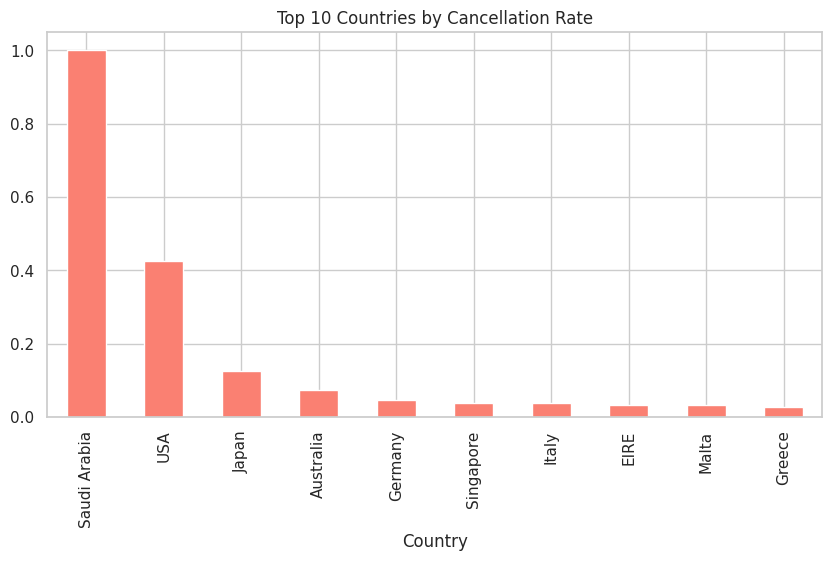

In [8]:
plt.figure(figsize=(10, 5))
cancel_rates = df_eda.groupby('Country')['IsCancelled'].mean().sort_values(ascending=False).head(10)
cancel_rates.plot(kind='bar', color='salmon')
plt.title('Top 10 Countries by Cancellation Rate')
plt.show()

<Figure size 1000x500 with 0 Axes>

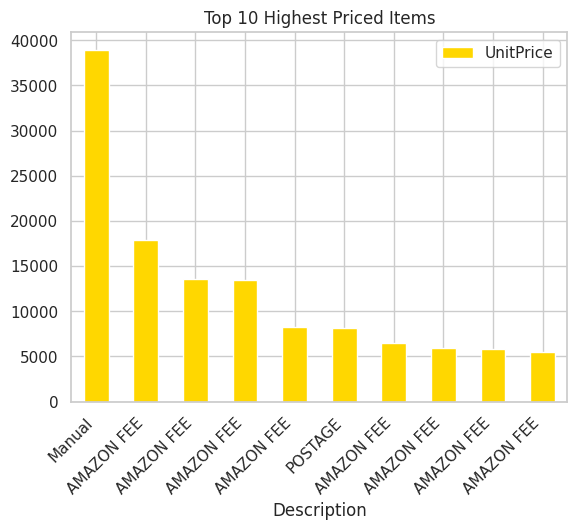

In [9]:
plt.figure(figsize=(10, 5))
df_eda[['Description', 'UnitPrice']].sort_values(by='UnitPrice', ascending=False).head(10).plot(kind='bar', x='Description', color='gold')
plt.title('Top 10 Highest Priced Items')
plt.xticks(rotation=45, ha='right')
plt.show()

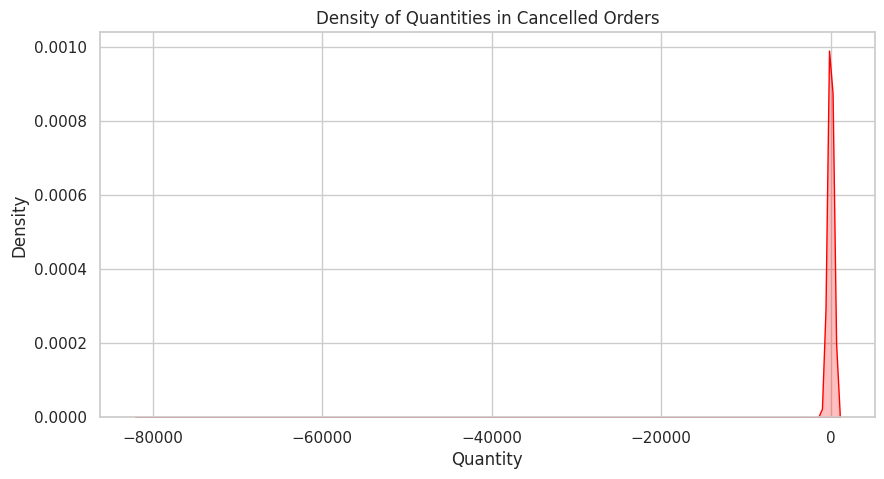

In [10]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_eda[df_eda['IsCancelled']==True]['Quantity'], shade=True, color='red')
plt.title('Density of Quantities in Cancelled Orders')
plt.show()

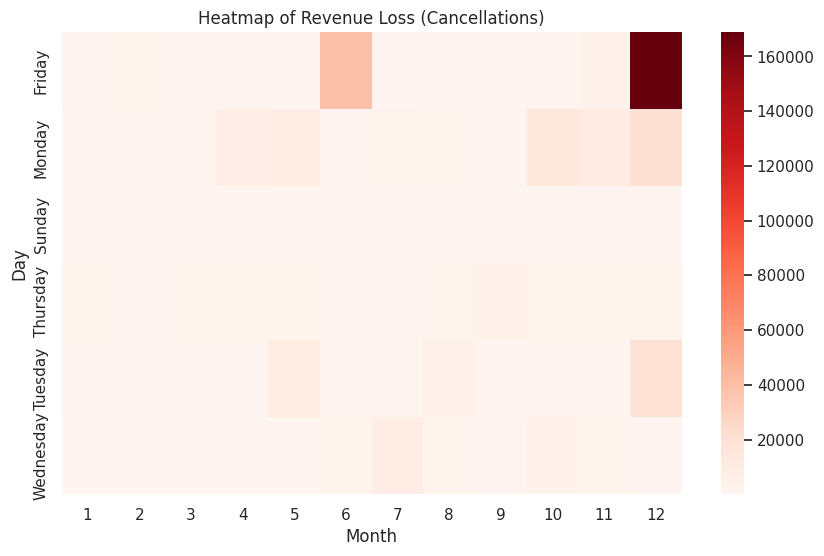

In [11]:
plt.figure(figsize=(10, 6))
loss_data = df_eda[df_eda['IsCancelled']==True].pivot_table(index='Day', columns='Month', values='Revenue', aggfunc='sum').abs()
sns.heatmap(loss_data, cmap='Reds')
plt.title('Heatmap of Revenue Loss (Cancellations)')
plt.show()

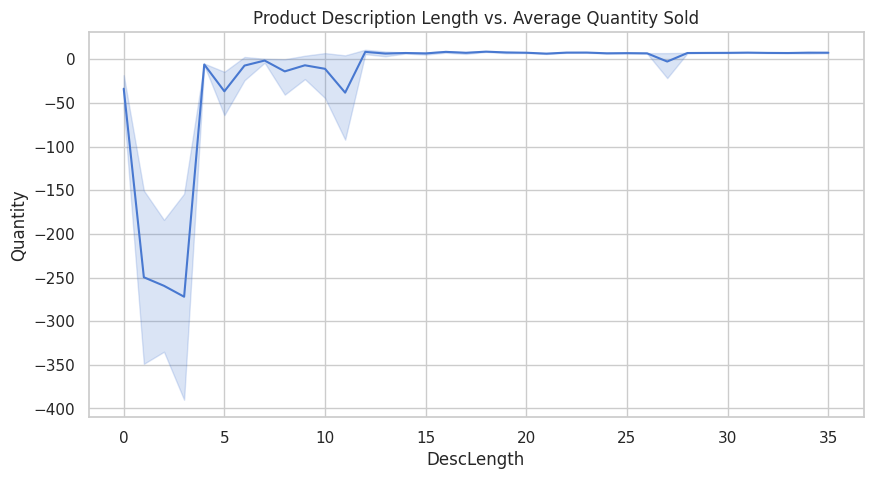

In [12]:
df_eda['DescLength'] = df_eda['Description'].str.len().fillna(0)
plt.figure(figsize=(10, 5))
sns.lineplot(x='DescLength', y='Quantity', data=df_eda[df_eda['Quantity'] < 100])
plt.title('Product Description Length vs. Average Quantity Sold')
plt.show()

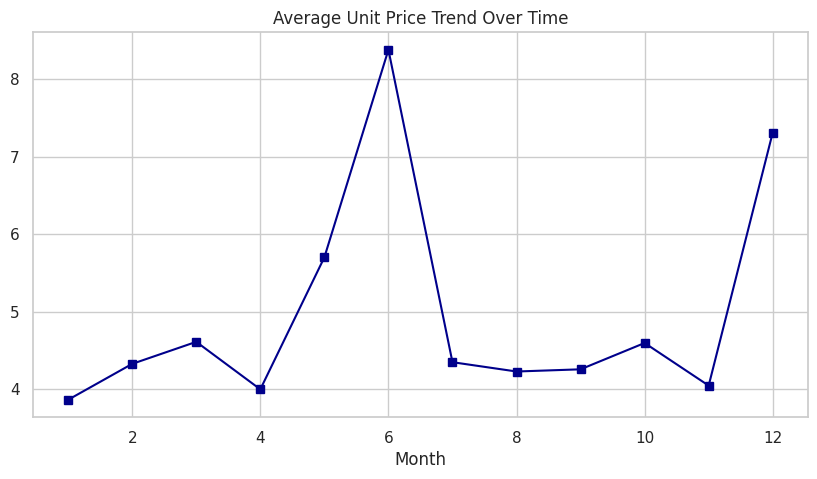

In [13]:
plt.figure(figsize=(10, 5))
df_eda.groupby('Month')['UnitPrice'].mean().plot(marker='s', color='darkblue')
plt.title('Average Unit Price Trend Over Time')
plt.show()

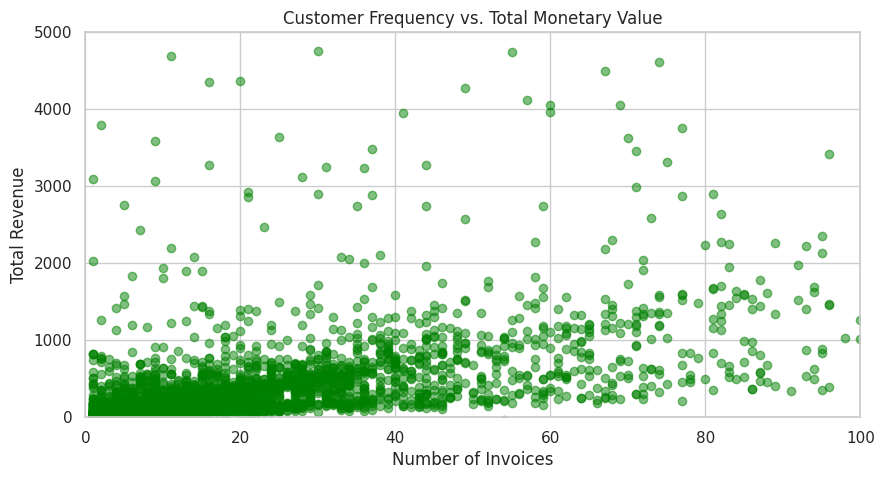

In [14]:
plt.figure(figsize=(10, 5))
customer_stats = df_eda.groupby('CustomerID').agg({'Revenue': 'sum', 'InvoiceNo': 'count'})
plt.scatter(customer_stats['InvoiceNo'], customer_stats['Revenue'], alpha=0.5, color='green')
plt.title('Customer Frequency vs. Total Monetary Value')
plt.xlabel('Number of Invoices'); plt.ylabel('Total Revenue')
plt.xlim(0, 100); plt.ylim(0, 5000)
plt.show()

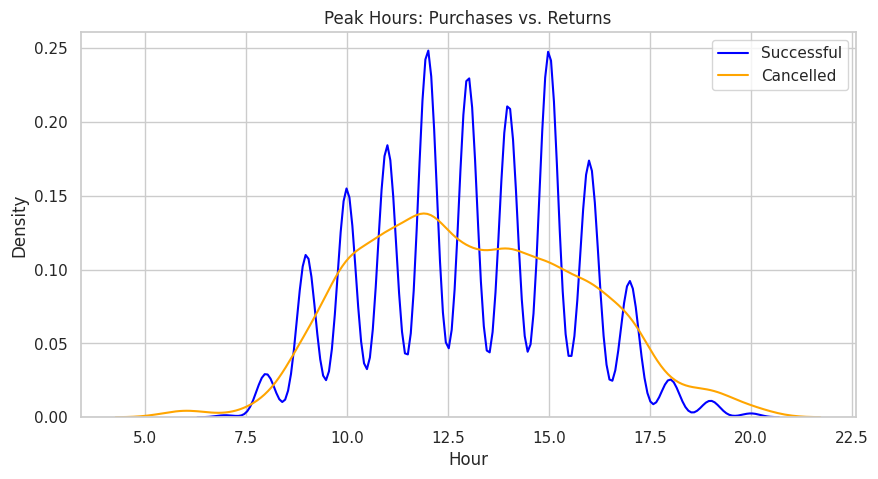

In [15]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_eda[df_eda['IsCancelled']==False]['Hour'], label='Successful', color='blue')
sns.kdeplot(df_eda[df_eda['IsCancelled']==True]['Hour'], label='Cancelled', color='orange')
plt.title('Peak Hours: Purchases vs. Returns')
plt.legend()
plt.show()

In [16]:
# ==========================================
# 3. PREPROCESSING & RANDOM OVER SAMPLING
# ==========================================
# Target: Is it a Cancellation?
df['Target'] = df['InvoiceNo'].str.startswith('C').fillna(False).astype(int)
X = df[['Quantity', 'UnitPrice']].fillna(0)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77)

# --- MANUAL RANDOM OVER SAMPLING ---
train_data = pd.concat([X_train, y_train], axis=1)
maj_class = train_data[train_data['Target'] == 0]
min_class = train_data[train_data['Target'] == 1]

min_upsampled = min_class.sample(len(maj_class), replace=True, random_state=77)
balanced_df = pd.concat([maj_class, min_upsampled]).sample(frac=1)

X_train_res = balanced_df.drop('Target', axis=1)
y_train_res = balanced_df['Target']

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [17]:
# ==========================================
# 4. 3 ML MODELS & COMPARISON (STUDENT 4)
# ==========================================
models = {
    "Random Forest (Entropy)": RandomForestClassifier(criterion='entropy', n_estimators=50),
    "Bagging Classifier": BaggingClassifier(n_estimators=50),
    "Gaussian NB": GaussianNB()
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    preds = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    })

In [18]:
# Ranking
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1
print("\n--- STUDENT 4: FINAL MODEL RANKING ---")
print(results_df)


--- STUDENT 4: FINAL MODEL RANKING ---
                     Model  Accuracy  Precision    Recall  F1-Score
1  Random Forest (Entropy)  1.000000   1.000000  1.000000  1.000000
2       Bagging Classifier  1.000000   1.000000  1.000000  1.000000
3              Gaussian NB  0.982248   0.166667  0.020225  0.036072


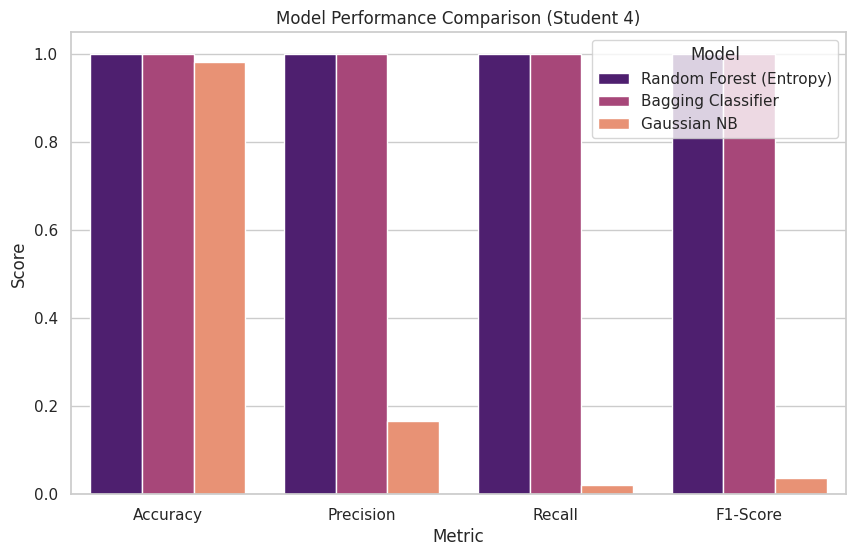

In [19]:
# Final Visualization
plt.figure(figsize=(10, 6))
metrics_melt = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melt, palette='magma')
plt.title('Model Performance Comparison (Student 4)')
plt.show()